 14. In this problem, you will develop a model to predict whether a given
 car gets high or low gas mileage based on the Auto data set.
 (a) Create a binary variable, mpg01, that contains a 1 if mpg contains
 a value above its median, and a 0 if mpg contains a value below
 its median. You can compute the median using the median()
 method of the data frame. Note you may find it helpful to add
 a column mpg01 to the data frame by assignment. Assuming you
 have stored the data frame as Auto, this can be done as follows:
 Auto['mpg01'] = mpg01

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

In [2]:
df=pd.read_csv(r"D:\ML&Fintech\data_ML&Fintech\Auto.csv")

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
median = df.mpg.median()
df.loc[(df['mpg'] >= median), 'mpg01'] = 1
df.loc[(df['mpg'] < median), 'mpg01'] = 0
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name,mpg01
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu,0.0
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320,0.0
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite,0.0
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst,0.0
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino,0.0


(b) Explore the data graphically in order to investigate the associ
ation between mpg01 and the other features. Which of the other
 features seem most likely to be useful in predicting mpg01? Scat
terplots and boxplots may be useful tools to answer this ques
tion. Describe your findings.

In [5]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,year,origin,mpg01
count,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000,397.000000
mean,23.515869,5.458438,193.532746,2970.261965,15.555668,75.994962,1.574307,0.503778
std,7.825804,1.701577,104.379583,847.904119,2.749995,3.690005,0.802549,0.500617
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000,0.000000
25%,17.500000,4.000000,104.000000,2223.000000,13.800000,73.000000,1.000000,0.000000
50%,23.000000,4.000000,146.000000,2800.000000,15.500000,76.000000,1.000000,1.000000
75%,29.000000,8.000000,262.000000,3609.000000,17.100000,79.000000,2.000000,1.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000,1.000000


In [6]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
mpg01           0
dtype: int64

In [7]:
df = df.replace('?', np.nan).dropna()

In [8]:
df_modified = df.drop('name', axis=1)

In [9]:
df_modified.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209,0.836939
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932,-0.759194
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535,-0.753477
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171,-0.667053
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005,-0.757757
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746,0.346822
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528,0.429904
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000,0.513698
mpg01,0.836939,-0.759194,-0.753477,-0.667053,-0.757757,0.346822,0.429904,0.513698,1.000000


Vehicles with lower weight, displacement, horsepower, and cylinder count are more likely to achieve high fuel economy (mpg01).

Engine-related variables are highly correlated with each other , indicating multicollinearity.

Acceleration has a weak-moderate positive relationship , meaning efficient vehicles tend to be lighter and thus accelerate better.

These variables can be used to classify cars into high/low MPG, with weight and displacement the strongest predictors.

MPG is strongly influenced by weight, displacement, cylinders, horsepower

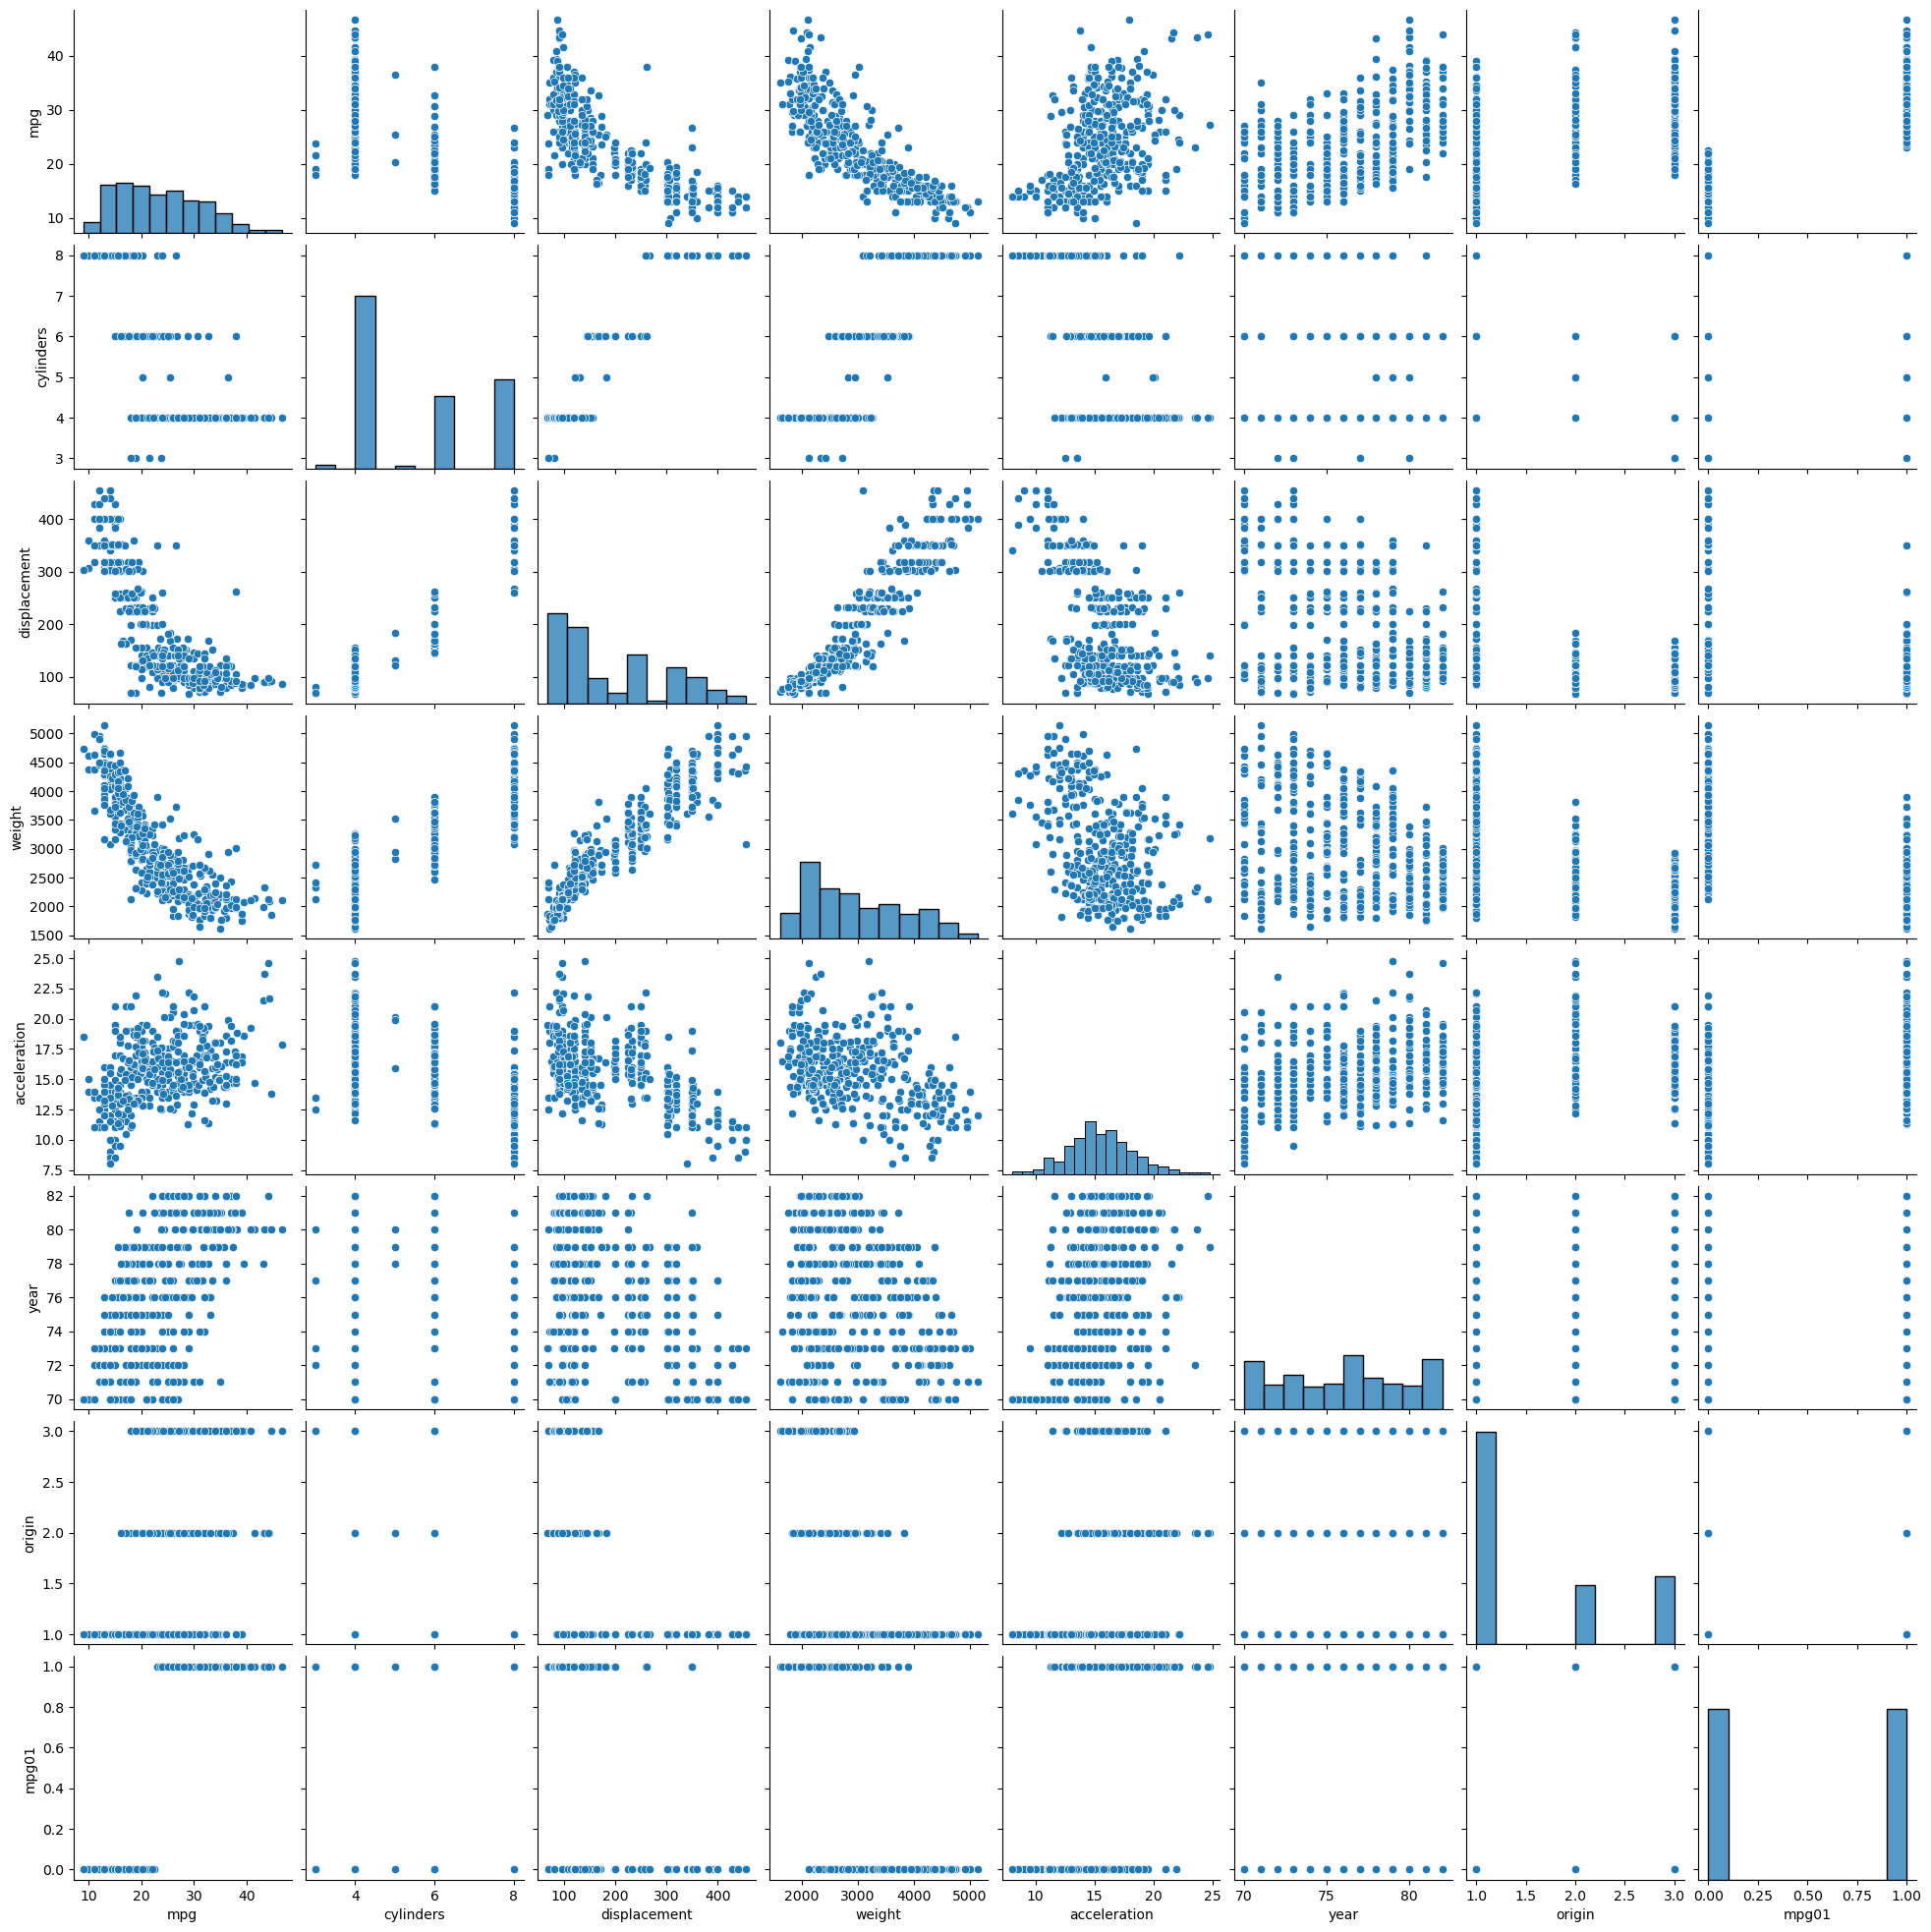

In [10]:
sns.pairplot(df)

 (c) Split the data into a training set and a test set.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.loc[:, ['cylinders', 'displacement', 'weight','horsepower']], df['mpg01'], train_size=0.7, random_state=1)

(d) Perform LDA on the training data in order to predict mpg01
 using the variables that seemed most associated with mpg01 in
 (b). What is the test error of the model obtained?

In [12]:
df_lda = LinearDiscriminantAnalysis()
df_lda.fit(X_train, y_train)

acc_score = accuracy_score(y_test, df_lda.predict(X_test))
print(f'Accuracy: {acc_score}')
print(f'LDA - Test Error: {1-acc_score}')

Accuracy: 0.9152542372881356
LDA - Test Error: 0.0847457627118644


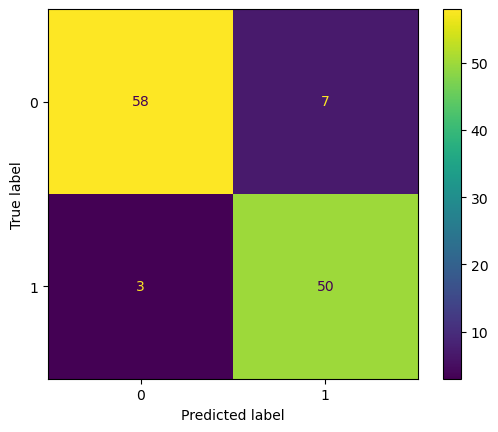

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, df_lda.predict(X_test)), display_labels=['0', '1'])
disp.plot()

 (e) Perform QDA on the training data in order to predict mpg01
 using the variables that seemed most associated with mpg01 in
 (b). What is the test error of the model obtained?

In [15]:
df_qda = QuadraticDiscriminantAnalysis()
df_qda.fit(X_train, y_train)

acc_score = accuracy_score(y_test, df_qda.predict(X_test))
print(f'Accuracy: {acc_score}')
print(f'QDA - Test Error: {1-acc_score}')

Accuracy: 0.923728813559322
QDA - Test Error: 0.07627118644067798


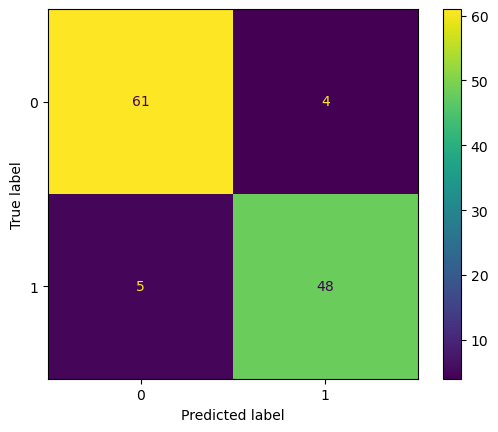

In [16]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, df_qda.predict(X_test)), display_labels=['0', '1'])
disp.plot()

(f) Perform logistic regression on the training data in order to pre
dict mpg01 using the variables that seemed most associated with
 mpg01 in (b). What is the test error of the model obtained?

In [17]:
df_logit = LogisticRegression(fit_intercept=True)
df_logit.fit(X_train, y_train)

acc_score = accuracy_score(y_test, df_logit.predict(X_test))
print(f'Accuracy: {acc_score}')
print(f'Logistic Regression - Test Error: {1-acc_score}')

Accuracy: 0.9152542372881356
Logistic Regression - Test Error: 0.0847457627118644


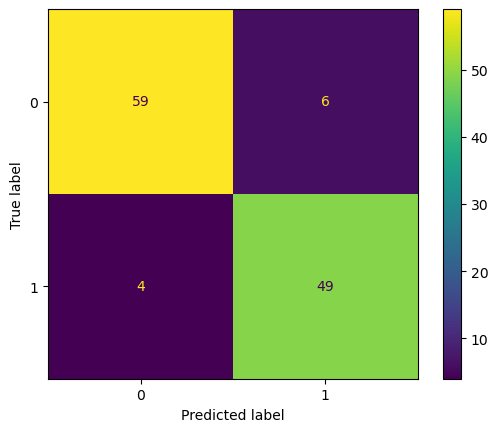

In [20]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, df_logit.predict(X_test)), display_labels=['0', '1'])
disp.plot()

 (g) Perform naive Bayes on the training data in order to predict
 mpg01 using the variables that seemed most associated with mpg01
 in (b). What is the test error of the model obtained?

In [21]:
df_naiveBayes = GaussianNB()
df_naiveBayes.fit(X_train, y_train)

acc_score = accuracy_score(y_test, df_naiveBayes.predict(X_test))
print(f'Accuracy: {acc_score}')
print(f'Naive Bayes - Test Error: {1-acc_score}')

Accuracy: 0.9152542372881356
Naive Bayes - Test Error: 0.0847457627118644


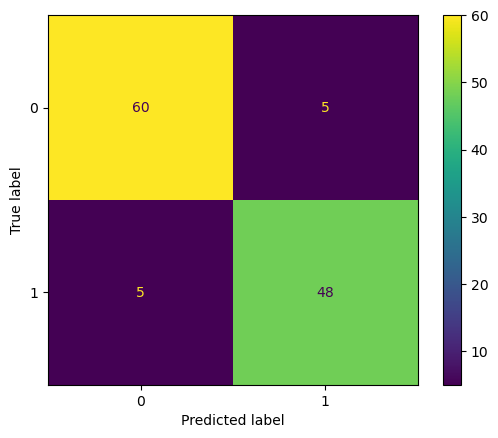

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, df_naiveBayes.predict(X_test)), display_labels=['0', '1'])
disp.plot()

 (h) Perform KNN on the training data, with several values of K, in
 order to predict mpg01. Use only the variables that seemed most
 associated with mpg01 in (b). What test errors do you obtain?
 Which value of K seems to perform the best on this data set?

In [23]:
k_values = [1, 10, 25, 50, 75,100]

for k in k_values:
    df_knn = KNeighborsClassifier(n_neighbors=k)
    df_knn.fit(X_train, y_train)
    
    acc_score = accuracy_score(y_test, df_knn.predict(X_test))
    print(f'K-value: {k}')
    print(f'Accuracy: {acc_score}')
    print(f'KNN - Test Error: {1-acc_score}')
    print('-'*20)

K-value: 1
Accuracy: 0.8813559322033898
KNN - Test Error: 0.11864406779661019
--------------------
K-value: 10
Accuracy: 0.9067796610169492
KNN - Test Error: 0.09322033898305082
--------------------
K-value: 25
Accuracy: 0.8898305084745762
KNN - Test Error: 0.11016949152542377
--------------------
K-value: 50
Accuracy: 0.8813559322033898
KNN - Test Error: 0.11864406779661019
--------------------
K-value: 75
Accuracy: 0.8728813559322034
KNN - Test Error: 0.1271186440677966
--------------------
K-value: 100
Accuracy: 0.8898305084745762
KNN - Test Error: 0.11016949152542377
--------------------


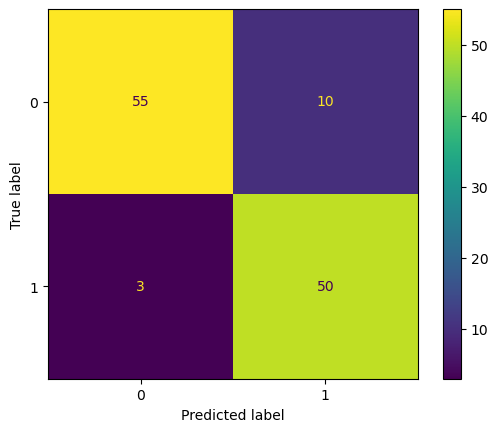

In [24]:
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, df_knn.predict(X_test)), display_labels=['0', '1'])
disp.plot()